# <a href="https://thetahat.ru/courses/ad">Введение в анализ данных</a>
## Домашнее задание 1. Простой анализ данных.


**Правила, <font color="red">прочитайте внимательно</font>:**

* Выполненную работу нужно отправить телеграм-боту `@thetahat_ds25_bot`. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайн см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**. Если вы строите интерактивные графики, их стоит прислать в формате html.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания всем участникам списывания дается штраф -2 балла к итоговой оценке за семестр.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*

<b><font size="5" color="red">Важно!!! Правила заполнения ноутбука:</font></b>
* Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения задач.
* Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз.
* Отвечайте на вопросы, а также добавляйте новые ячейки в предложенных местах, которые обозначены `<...>`.
* В markdown-ячейка, содержащих описание задачи, находятся специальные отметки, которые <font color="red"><b>запрещается модифицировать</b></font>.
* При нарушении данных правил работа может получить 0 баллов.


**Перед выполнением задания посмотрите презентацию по выполнению и оформлению домашних заданий с занятия 2.**


**Баллы за задание:**

<b><font color="blue">Легкая часть</font></b> (достаточно на "хор"):
* Задача 1 &mdash; 30 баллов
* Задача 2 &mdash; 90 баллов

Баллы учитываются в <b>обязательной части</b> курса и не влияют на оценку по факультативной части.

In [2]:
# Bot check

# HW_ID: fpmi_ad1
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную

#### Тренировочные задачи на библиотеки

Если вы неуверенно себя чувствуете в библиотеках numpy, pandas, matplotlib, seaborn, рекомендуем сначала
* посмотреть материалы по библиотекам на нашем сайте
* прорешать упражнения на библиотеки на странице курса
* прорешать <a href="https://contest.yandex.ru/contest/75090/enter/">два упражнения на numpy</a> в системе Яндекс.Контест.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 9ede240862d9bf1602556040405c317e -->
---
### <font color="blue"><i>Легкая часть</i></font>

### Задача 1

На семинаре мы разбирали классификацию изображений на основе kNN. В этом задании мы вернемся к датасету [MNIST](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html) и попробуем улучшить результат, полученный на семинаре.

Для начала, загрузите данные и разделите их на обучающую и тестовую части.

In [1]:
!pip install scikit-learn

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# обратите внимание, что Scikit-Learn импортируется как sklearn
from sklearn import datasets
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# фиксируем seed для воспроизводимости результатов
random_state = 42

In [2]:
# загружаем датасет MNIST и урезанную версию этого датасета, а затем разделим данные и переведём их в вектор

mnist = fetch_openml("mnist_784")
digits = datasets.load_digits()
n_samples = len(digits["images"])
X, y = digits["images"].reshape(n_samples, -1), digits["target"]

X.shape, y.shape

((1797, 64), (1797,))

In [3]:
# Разделим данные на тренировочную выборку и тестовую.

X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size = 0.7, random_state = random_state
)

Число соседей в модели kNN является необучаемым параметром т.е. гиперпараметром который выставляется вручную. Как мы видели на лекции, выбор оптимального значения $k$ важен, так как слишком маленькое значение может привести к переобучению, а слишком большое — к недообучению.

Постройте график зависимости точности (`accuracy_score`) предсказания kNN от значения $k$ (от 1 до 20) для обучающей и тестовой выборок.

In [4]:
# Было решено сделать перебор параметра k циклом for, и на каждой итерации вычилить точность и запомнить её

In [4]:
# Было созданы списки для хранения точности на обучающей и тестовой выборках
model_train_accuracy_first = []
model_test_accuracy_first = []

for k in range(20) :

    # для каждого k была создана брутфорсная модель
    model_first = KNeighborsClassifier(n_neighbors = k + 1, algorithm = "brute")

    # затем она была обучена на обучающей выборке
    model_first.fit(X_train, y_train)

    # после того, как модель была обучена, она была использована для предсказаний на тестовой и обучающей выборках
    y_test_pred_first = model_first.predict(X_test)
    y_train_pred_first = model_first.predict(X_train)

    # и были записаны результаты сравнения выборок
    model_train_accuracy_first.append(accuracy_score(y_train, y_train_pred_first))
    model_test_accuracy_first.append(accuracy_score(y_test, y_test_pred_first))

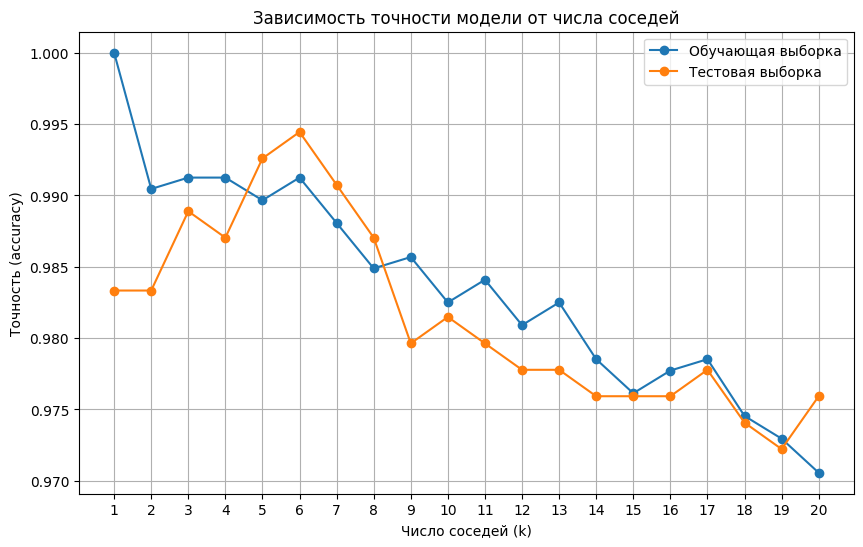

In [6]:
# после получения необходимых данных были построены простые типичные графики для обеих выборок
# ньюанс: для построения графика нужно было создать список значений k k_values

k_values = range(1, 21)
plt.figure(figsize=(10, 6))
plt.plot(k_values, model_train_accuracy_first, label = "Обучающая выборка", marker = 'o')
plt.plot(k_values, model_test_accuracy_first, label = "Тестовая выборка", marker = 'o')
plt.xlabel("Число соседей (k)")
plt.ylabel("Точность (accuracy)")
plt.title("Зависимость точности модели от числа соседей")
plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.show()

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- fe9171a6e245a953987df27f018c61c2 -->
&#x2753; **Вопрос** &#x2753;

> Почему при $k = 1$ на тренировочной выборке метрика качества составляет 100%.

**Ваш ответ:** потому что, поскольку выборки совпадают, у каждого соседа единственный ближайший сосед это он сам.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- cdb15caec1719ca7ba80d25b716879ca -->
Помимо числа соседей гиперпараметром модели также является *метрика расстояния* между объектами.

> По умолчанию используется *Евклидова метрика* ($L_2$), согласно которой расстояние между двумя точками $x_1 =(x_{11}, …, x_{1d})$ и $x_2=(x_{21},…,x_{2n})$ в $d$-мерном пространстве определяется как:
$$\rho(x_1, x_2) = \sqrt{\sum^d_{j=1}\left(x_{1j} - x_{2j}\right)^2}.$$
>
> Иногда в kNN имеет смысл использовать другие метрики, например *метрику Манхэттена* ($L_1$).
$$\rho(x_1, x_2) = \sum^d_{j=1} \left|x_{1j} - x_{2j}\right|.$$
>
> Выбор одной из них зависит от особенностей задачи и данных. В частности,
>
> * метрика Манхэттена менее чувствительна к выбросам, чем евклидово расстояние, что делает её полезной для данных с сильным шумом или при наличии аномалий;
>
> * в задачах с разреженными данными (например, текстовые данные, представленные в виде векторов) метрика Манхэттена может работать лучше, чем евклидово расстояние.

Проведите аналогичный эксперимент используя в качестве гиперпараметра $L_1$-метрику (выясните сами, как ее задать). Выведите на одном графике зависимости точности (accuracy) от значения $k$ для обучающей и тестовой выборок для обоих метрик.

In [7]:
# всё, что нужно поменять, это параметр в задании кнн модели metric = "manhattan"

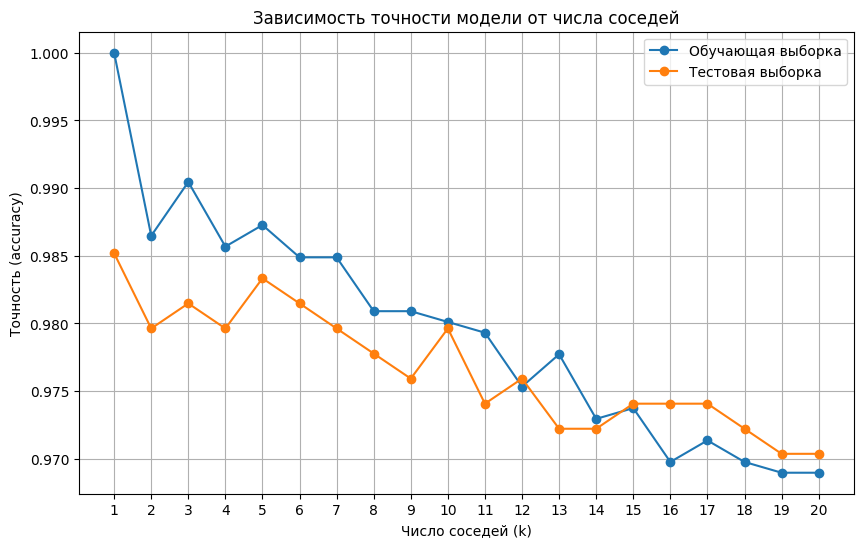

In [8]:
# Было созданы списки для хранения точности на обучающей и тестовой выборках
model_train_accuracy_second = []
model_test_accuracy_second = []

for k in range(20) :

    # для каждого k была создана брутфорсная модель
    model_second = KNeighborsClassifier(n_neighbors = k + 1, algorithm = "brute", metric = "manhattan")

    # затем она была обучена на обучающей выборке
    model_second.fit(X_train, y_train)

    # после того, как модель была обучена, она была использована для предсказаний на тестовой и обучающей выборках
    y_test_pred_second = model_second.predict(X_test)
    y_train_pred_second = model_second.predict(X_train)

    # и были записаны результаты сравнения выборок
    model_train_accuracy_second.append(accuracy_score(y_train, y_train_pred_second))
    model_test_accuracy_second.append(accuracy_score(y_test, y_test_pred_second))

# после получения необходимых данных были построены простые типичные графики для обеих выборок
# ньюанс: для построения графика нужно было создать список значений k k_values
k_values = range(1, 21)
plt.figure(figsize=(10, 6))
plt.plot(k_values, model_train_accuracy_second, label = "Обучающая выборка", marker = 'o')
plt.plot(k_values, model_test_accuracy_second, label = "Тестовая выборка", marker = 'o')
plt.xlabel("Число соседей (k)")
plt.ylabel("Точность (accuracy)")
plt.title("Зависимость точности модели от числа соседей")
plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.show()

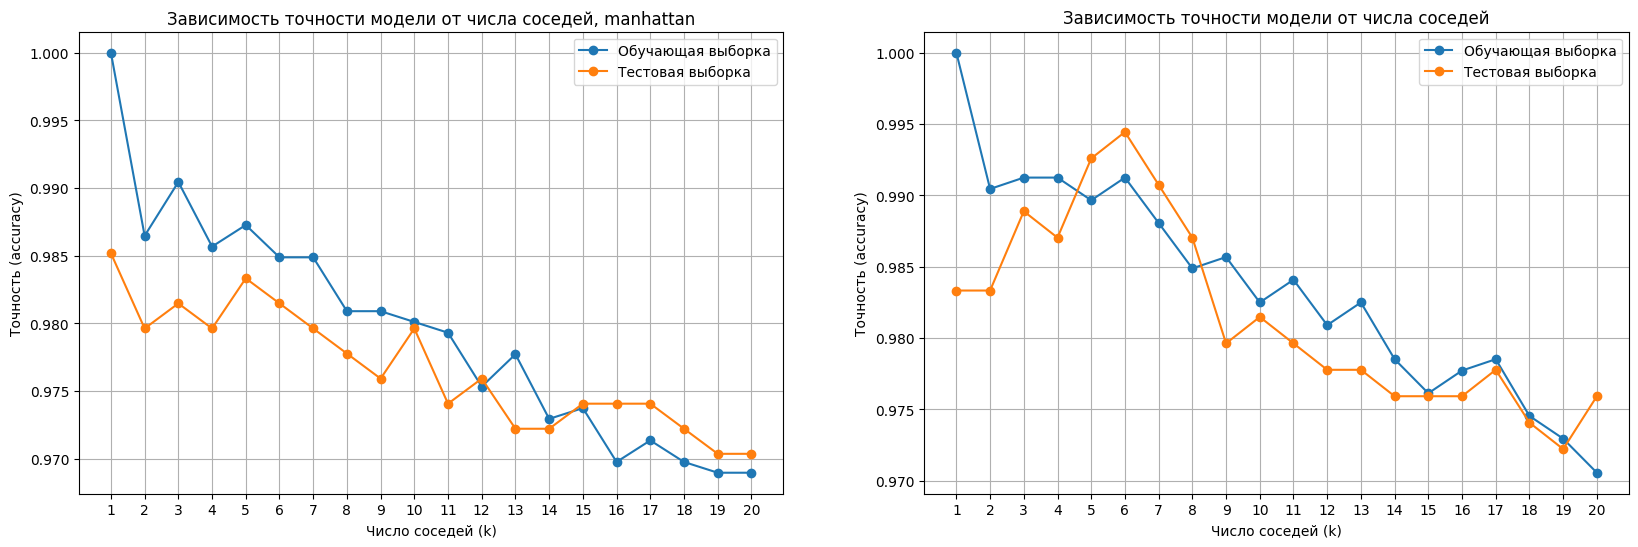

In [9]:
# Создаем фигуру и два подграфика
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))

# Первый график
ax1.plot(k_values, model_train_accuracy_second, label="Обучающая выборка", marker='o')
ax1.plot(k_values, model_test_accuracy_second, label="Тестовая выборка", marker='o')
ax1.set_xlabel("Число соседей (k)")
ax1.set_ylabel("Точность (accuracy)")
ax1.set_title("Зависимость точности модели от числа соседей, manhattan")
ax1.legend()
ax1.grid(True)
ax1.set_xticks(k_values)

# Второй график
ax2.plot(k_values, model_train_accuracy_first, label="Обучающая выборка", marker='o')
ax2.plot(k_values, model_test_accuracy_first, label="Тестовая выборка", marker='o')
ax2.set_xlabel("Число соседей (k)")
ax2.set_ylabel("Точность (accuracy)")
ax2.set_title("Зависимость точности модели от числа соседей")
ax2.legend()
ax2.grid(True)
ax2.set_xticks(k_values)

# Отображаем графики
plt.show()

&#x2754; **Вопрос** &#x2754;

> Как вы думаете почему смена метрики так сильно повлияла на характер кривых?

**Ваш ответ:** учитывая описанные пункты хорошести манхэтенновской метрики, можно сделать вывод, что либо много выбросов, либо разреженные данные. Но если внимательно присмотреться к характерному падению точности тестовой выборки в районе k = 6 (где не низка чувствительность к выбросам), то можно заметить, что скорее всего причина не в выбросах, а скорее в чём-то другом, в разреженности, например.

**Выводы:** Были проведены эксперименты в качестве начального знакомства с библиотеками анализа данных в python. Эксперименты показали, что хотя метрика может быть лучше в общем, однако на некоторых датасетах она может давать худший результат. Также на графиках при обеих метриках наблидается падение точности с ростом k, это предсказывает теория. Оптимальный результат в районе 5 - 6 соседей.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 00000000000000000000000000000000 -->


---

### Задача 2

Перед выполнением задачи рекомендуется посмотреть <a href="https://thetahat.ru/courses/ad/main/1/main_sem_kNN">материал</a> с семинара.

#### 0. Подготовка данных

Титаник был крупнейшим пассажирским судном в 1912—1913 годах. Во время первого рейса затонул в северной Атлантике, столкнувшись с айсбергом в ночь с 14 на 15 апреля 1912 года, при этом погибло 1502 из 2224 пассажиров и членов экипажа. Данные о пассажирах были собраны в таблицы, которые можно скачать с <a href="https://www.kaggle.com/c/titanic/data" target="_blank">Kaggle</a>. Эти данные часто используются в качестве обучающих в анализе данных.


Загрузите данные с помощью `pandas`.

In [5]:
import pandas as pd

titanic = pd.read_csv(r"C:\Users\Name\OneDrive\Документы\MIPT\AD\titanic\train.csv")
titanic.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Для лучшего понимания процесса работы с данными, уточним ключевые термины.

> **Объект** — это единица данных, представленная набором признаков и используемая для обучения или предсказаний модели. В данной задаче являются пассажиры, им соответствуют *строки* таблицы данных.
>
> **Признаки (features)** — это характеристики, которые описывают объекты в данных. В таблицах данных они обычно соответствуют *колонкам*. В данной задаче мы будем работать со следующими признаками
>
> * `Pclass` — класс билета (1 = первый класс, 2 = второй класс, 3 = третий класс);
>
> * `Age` — возраст пассажира;
>
> * `SibSp` — количество братьев, сестер или супругов на борту;
>
> * `Parch` — количество родителей или детей на борту;
>
> * `Fare` — стоимость билета.
>
> **Таргет (target)** — это целевая переменная, которую мы хотим предсказать. В данной задаче мы будем предсказывать `Survived` — бинарная переменная, указывающая, выжил ли пассажир (1) или нет (0). Значения этой переменной имеются для обучающего набора данных, а для тестого — нет.

Из каждой части оставим несколько признаков, с которыми мы будем работать, а также отдельно &mdash; целевой признак, который мы хотим предсказать.

In [6]:
features_columns = ["Pclass", "Age", "Sex", "SibSp", "Parch", "Fare"]
target_column = "Survived"  # Целевой признак

X, y = titanic[features_columns], titanic[target_column]

В данных могут присутствовать пропуски. Пока что мы не умеем с ними работать, так что исключим из данных.

Посмотрите, сколько объектов имеют хотя бы один пропуск. Удалите их из данных.

In [7]:
# считаем количесвто строк X и ячеек y, содержащих хотя бы один нуль
sum_na_X = X.isnull().any(axis = 1).sum()
sum_na_y = y.isna().sum()

print(sum_na_X, sum_na_y)
print("\n")

# удаляем объекты с нулевыми значениями, и не забываем с удалением строки в X удалить элемент в y

mask = X.isnull().any(axis=1)  # Маска для строк с пропусками в X
X = X[~mask]  # Удаляем строки с пропусками из X
y = y[~mask]  # Удаляем соответствующие строки из y

# проверяем, остались ли нули

print(y.isna().any())
print("\n")
print(X.isnull().sum())

177 0


False


Pclass    0
Age       0
Sex       0
SibSp     0
Parch     0
Fare      0
dtype: int64


Разделите данные по строкам на две части случайным образом в соотношении 7:3. Первую часть мы будем называть *обучающей*, а вторую &mdash; *тестовой*.

In [8]:
# делаем по шаблону

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 371b31e8ca86989a98cce342afcbbf2a -->
#### 1. Исследование

> &#x2757; **Внимание.** Эта часть задачи должна выполняться *исключительно на обучающих данных*. За использование тестовых данных решение не будет оценено.

Проведите визуальный анализ данных чтобы понять, как различные признаки влияют на целевой. Исследовать можно не целиком обучающие данные, а разделить их на две части по одному из признаков, а далее рассматривать каждую часть отдельно.

*Не забывайте про информативность и эстетичность графиков, посмотрите презентацию про оформление домашних заданий.*

Влияние пола на выживаемость

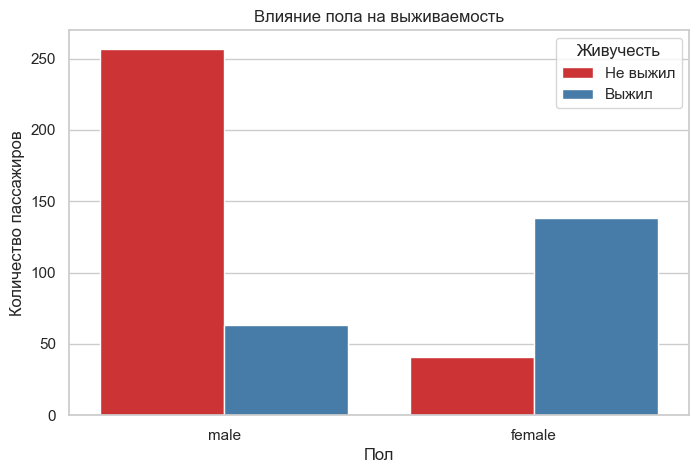

In [11]:
import seaborn as sns

# Добавляем целевую переменную в обучающую выборку для анализа
train_data = X_train.copy()
train_data[target_column] = y_train

# Разделяем данные по половому признаку
male_data = train_data[train_data["Sex"] == "male"]
female_data = train_data[train_data["Sex"] == "female"]

# Оказалось, что можно настроить стиль графиков
sns.set(style = "whitegrid")

# 1. Влияние пола на выживаемость
plt.figure(figsize = (8, 5))
sns.countplot(x = "Sex", hue = "Survived", data = train_data, palette = "Set1")
plt.title("Влияние пола на выживаемость")
plt.xlabel("Пол")
plt.ylabel("Количество пассажиров")
plt.legend(title = "Живучесть", loc = "upper right", labels = ["Не выжил", "Выжил"])
plt.show()

Влияние возраста на выживаемость (мужчины и женщины отдельно)

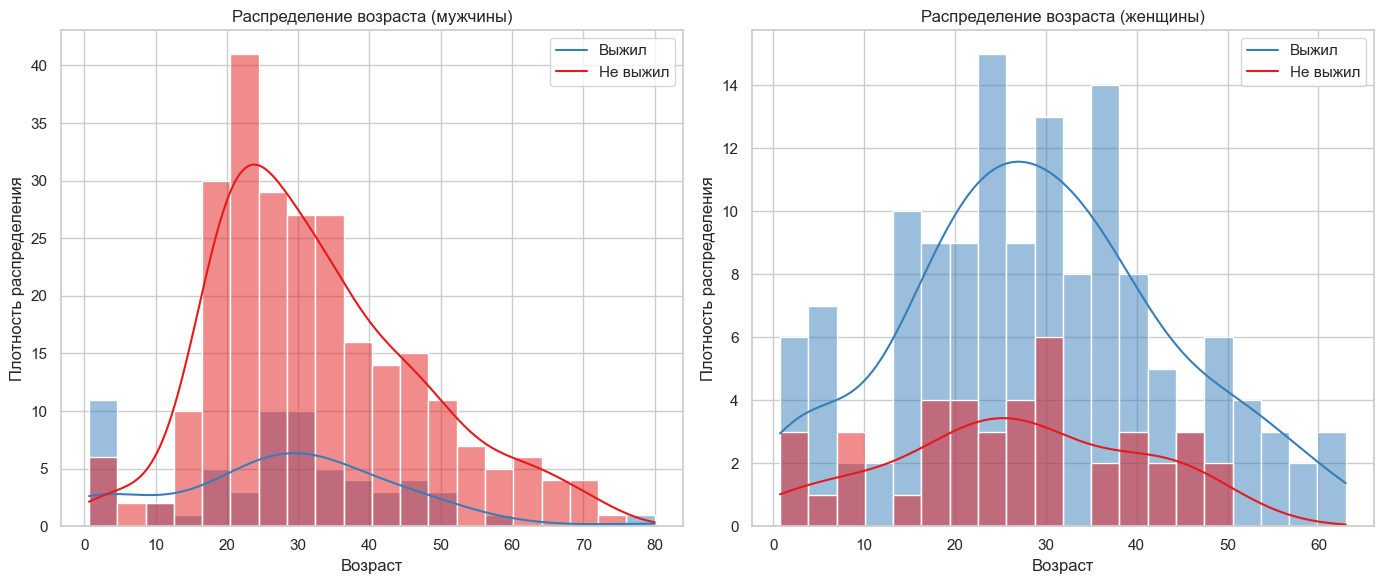

In [20]:
# 2. Влияние возраста на выживаемость (мужчины и женщины отдельно) - ИСПРАВЛЕННАЯ ВЕРСИЯ
plt.figure(figsize=(14, 6))

# среди мужчин (с нормализацией внутри группы выживших/не выживших)
plt.subplot(1, 2, 1)
sns.histplot(data=male_data, x="Age", hue="Survived", kde=True, 
             palette="Set1", bins=20, common_norm=False)
plt.title("Распределение возраста (мужчины)")
plt.xlabel("Возраст")
plt.ylabel("Плотность распределения")
plt.legend(title="", loc="upper right", labels=["Выжил", "Не выжил"])

# среди женщин (с нормализацией внутри группы выживших/не выживших)
plt.subplot(1, 2, 2)
sns.histplot(data=female_data, x="Age", hue="Survived", kde=True,
             palette="Set1", bins=20, common_norm=False)
plt.title("Распределение возраста (женщины)")
plt.xlabel("Возраст")
plt.ylabel("Плотность распределения")
plt.legend(title="", loc="upper right", labels=["Выжил", "Не выжил"])

plt.tight_layout()
plt.show()

Влияние класса каюты на выживаемость (мужчины и женщины отдельно)

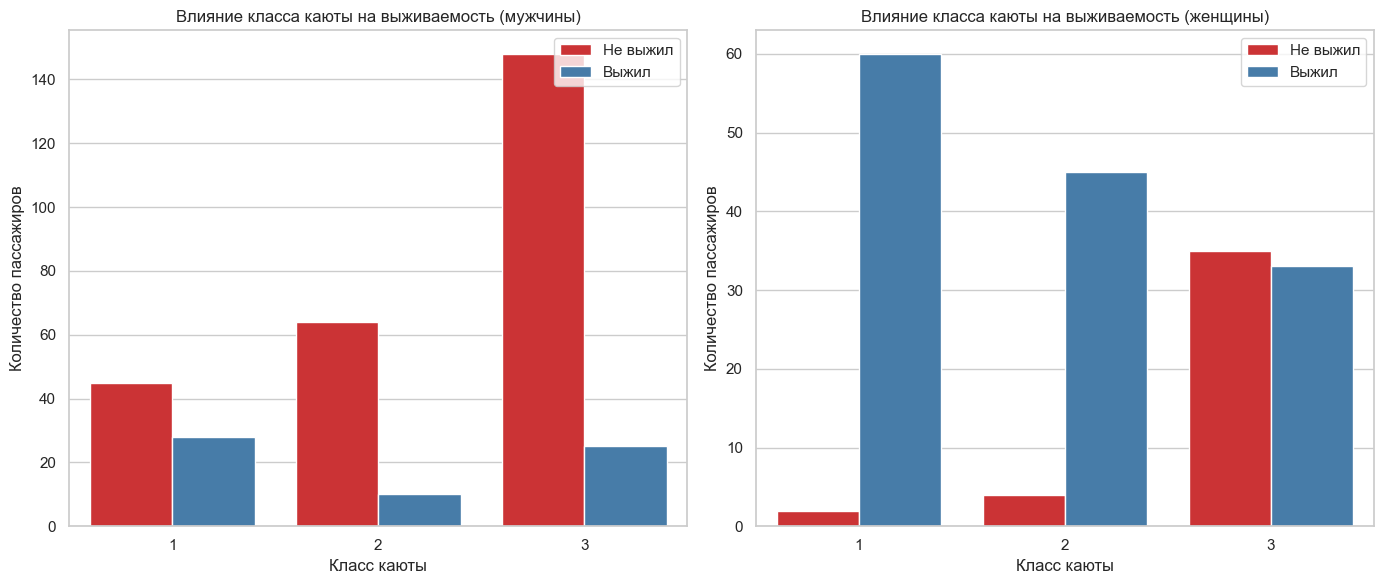

In [18]:
# 3. Влияние класса каюты на выживаемость (мужчины и женщины отдельно)
plt.figure(figsize = (14, 6))

# среди мужчин
plt.subplot(1, 2, 1)
sns.countplot(x = "Pclass", hue = "Survived", data = male_data, palette = "Set1")
plt.title("Влияние класса каюты на выживаемость (мужчины)")
plt.xlabel("Класс каюты")
plt.ylabel("Количество пассажиров")
plt.legend(title = "", loc = "upper right", labels = ["Не выжил", "Выжил"])

# среди женщин
plt.subplot(1, 2, 2)
sns.countplot(x = "Pclass", hue = "Survived", data = female_data, palette = "Set1")
plt.title("Влияние класса каюты на выживаемость (женщины)")
plt.xlabel("Класс каюты")
plt.ylabel("Количество пассажиров")
plt.legend(title = "", loc = "upper right", labels = ["Не выжил", "Выжил"])

plt.tight_layout()
plt.show()

Влияние стоимости билета на выживаемость (мужчины и женщины отдельно)

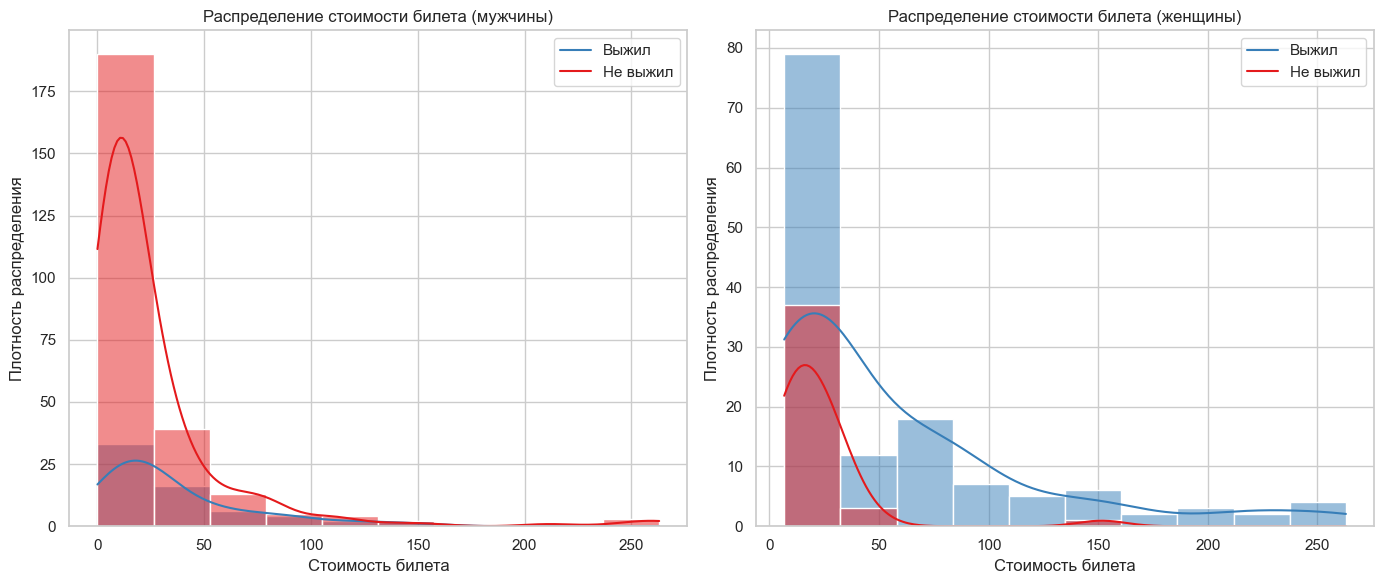

In [21]:
# 4. Влияние стоимости билета на выживаемость (мужчины и женщины отдельно) - ИСПРАВЛЕННАЯ ВЕРСИЯ
plt.figure(figsize=(14, 6))

# среди мужчин (с нормализацией)
plt.subplot(1, 2, 1)
sns.histplot(data=male_data, x="Fare", hue="Survived", kde=True,
             palette="Set1", bins=10, common_norm=False)
plt.title("Распределение стоимости билета (мужчины)")
plt.xlabel("Стоимость билета")
plt.ylabel("Плотность распределения")
plt.legend(title="", loc="upper right", labels=["Выжил", "Не выжил"])

# среди женщин (с нормализацией)
plt.subplot(1, 2, 2)
sns.histplot(data=female_data, x="Fare", hue="Survived", kde=True,
             palette="Set1", bins=10, common_norm=False)
plt.title("Распределение стоимости билета (женщины)")
plt.xlabel("Стоимость билета")
plt.ylabel("Плотность распределения")
plt.legend(title="", loc="upper right", labels=["Выжил", "Не выжил"])

plt.tight_layout()
plt.show()

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 476dce11b8cac8705a10bff695e4cdee -->
#### 2. Классификация логическими правилами

На основе выше проведенного исследования предложите два разных правила в виде решающего дерева, пример которого можете посмотреть в презентации с первой лекции (классификация котиков). Никакие статистические методы использовать не требуется, только логику и графики. Любые решения "из коробки" использовать запрещено. Например, достаточно пояснения "*по графику (описание графика) визуально я увидел, что при X > 100 большинство пассажиров выжило, поэтому использую правило (описание правила)*".

В данной задаче достаточно, если первое дерево будет иметь максимальную глубину 2, а второе &mdash; глубину 1, и при этом не является поддеревом первого. Дерево из одного листа имеет глубину 0.

*Указание*. Попросите ИИ красиво оформить описание дерева и его пояснение.

**Дерево 1:**

Решающее дерево глубины 2
Описание правила:

    Первый уровень (глубина 1):

        Если пассажир — женщина (Sex == "female"), переходим ко второму уровню.

        Если пассажир — мужчина (Sex == "male"), предсказываем "Не выжил".

    Второй уровень (глубина 2):

        Если женщина находится в первом или втором классе (Pclass == 1 или Pclass == 2), предсказываем "Выжил".

        Если женщина находится в третьем классе (Pclass == 3), предсказываем "Не выжил".

Обоснование:

    По графику "Влияние пола на выживаемость" видно, что женщины выживали чаще, чем мужчины.

    По графику "Влияние класса каюты на выживаемость" видно, что пассажиры первого и второго класса выживали чаще, чем пассажиры третьего класса.

**Дерево 2:**

Решающее дерево глубины 1
Описание правила:

    Если пассажир — ребенок (возраст меньше 10 лет, Age < 10), предсказываем "Выжил".

    Иначе предсказываем "Не выжил".

Обоснование:

    По графику "Распределение возраста" видно, что дети (особенно мальчики) выживали чаще, чем взрослые.

In [2]:
import graphviz
graphviz.__version__  # Должна показать версию

'0.20.3'

In [10]:
import os
path = r'C:\Users\Name\AD_Name\windows_10_cmake_Release_Graphviz-12.2.1-win64\Graphviz-12.2.1-win64\bin\dot.exe'
print("Файл существует:", os.path.exists(path))

Файл существует: True


In [12]:
import os
os.environ["PATH"] += os.pathsep + r'C:\Users\Name\AD_Name\windows_10_cmake_Release_Graphviz-12.2.1-win64\Graphviz-12.2.1-win64\bin'

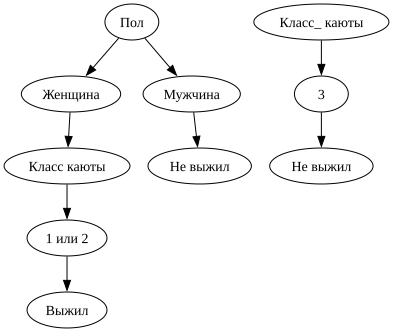

In [16]:
from graphviz import Digraph
from IPython.display import display

# Создаем объект графа
dot = Digraph(comment='Решающее дерево')
dot.graph_attr['rankdir'] = 'TB'

# Добавляем узлы
dot.node('Пол', 'Пол')
dot.node('Женщина', 'Женщина')
dot.node('Мужчина', 'Мужчина')
dot.node('Класс_каюты', 'Класс каюты')
dot.node('1_или_2', '1 или 2')
dot.node('3', '3')
dot.node('Выжил', 'Выжил')
dot.node('Не_выжил_1', 'Не выжил')
dot.node('Не_выжил_2', 'Не выжил')

# Соединяем узлы
dot.edge('Пол', 'Женщина',)
dot.edge('Пол', 'Мужчина',)
dot.edge('Женщина', 'Класс_каюты')
dot.edge('Мужчина', 'Не_выжил_1')
dot.edge('Класс_каюты', '1_или_2')
dot.edge('Класс_ каюты', '3')
dot.edge('1_или_2', 'Выжил')
dot.edge('3', 'Не_выжил_2')

# Отображаем граф
display(dot)

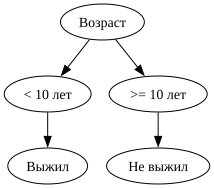

In [21]:
# Создаем объект графа
dot = Digraph(comment='Решающее дерево')

# Добавляем узлы
dot.node('Возраст', 'Возраст')
dot.node('Меньше_10', '< 10 лет')
dot.node('Больше_или_равно_10', '>= 10 лет')
dot.node('Выжил', 'Выжил')
dot.node('Не_выжил', 'Не выжил')

# Соединяем узлы
dot.edge('Возраст', 'Меньше_10')
dot.edge('Возраст', 'Больше_или_равно_10')
dot.edge('Меньше_10', 'Выжил')
dot.edge('Больше_или_равно_10', 'Не_выжил')

# Отображаем граф
display(dot)

Реализуйте полученные деревья по шаблону

In [22]:
def tree_first(features: pd.DataFrame) -> pd.Series:
    """
    Предсказание целевого признака для данных features -- pandas-таблица данных.
    Возвращает pandas.Series с теми же индексами, что и у features.
    """
    # Используем numpy.where для создания условий
    predicted = pd.Series(0, index=features.index)

    # Условие для мужчин
    predicted = predicted.mask(features['Sex'] == 'male', 0)

    # Условие для женщин из 3 класса
    predicted = predicted.mask((features['Sex'] == 'female') & (features['Pclass'] == 3), 0)

    # Условие для всех остальных
    predicted = predicted.mask(predicted == 0, 1)

    return predicted

In [23]:
def tree_second(features: pd.DataFrame) -> pd.Series:
    """
    Предсказание целевого признака для данных features -- pandas-таблица данных.
    Возвращает pandas.Series с теми же индексами, что и у features.
    """
    # Используем numpy.where для создания условий
    predicted = pd.Series(0, index=features.index)

    # Условие для возраста меньше 10
    predicted = predicted.mask(features['Age'] < 10, 1)

    return predicted

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 509cca15393d5b0fb3cf40b463d12077 -->
Проверьте работоспособность данных моделей на тестовой выборке и оцените качество модели по метрике `accuracy`.

> &#x2755; *Примечание.* Полученные значения не влияют на оценку по заданию. Оценивается только корректность и обоснованность решения, а также графики и выводы.

In [24]:
def accuracy(target: pd.Series, predicted: pd.Series) -> float:
    """
    Вычисление критерия качества для предсказания predicted,
    если истинные значения -- target.
    Возвращает одно вещественное число.
    """
    return accuracy_score(target, predicted)

In [25]:
predicted_first_test = tree_first(X_test) # запускаем первую дерево-модель на тестовых данных
predicted_second_test = tree_second(X_test) # запускаем вторую дерево-модель на тестовых данных

print(round(accuracy(y_test, predicted_first_test), 2), round(accuracy(y_test, predicted_second_test), 2))

0.78 0.6


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 2bf781f25f8969f7e712ea5d28d608a3 -->
#### 3. Классификация методом ближайшего соседа

В данной части задачи оставим только признаки `'Pclass'`, `'Age'`, `'Sex'`,`'Fare'`.


&#x2753; **Вопрос** &#x2753;
> Какие могли бы возникнуть проблемы при использовании признаков `'SibSp'`, `'Parch'`? Имеется ли подобная проблема для признака `'Pclass'`?

**Ваш ответ:** Проблемы признаков 'SibSp' и 'Parch' в KNN несопоставимости с другими признаками. Переход от 0 - 1 (нет семьи → есть семья) важнее, чем от 1 - 2, KNN не учитывает эту нелинейность. "Pclass" является порядковым (1-й класс > 2-й > 3-й), его можно использовать как число, но разница между 1-2 и 2-3 может не быть равнозначной.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 3bfbe10cf933e1302c2f524a99acfa54 -->
Постройте классификатор методом ближайшего соседа. Обучите его и оцените качество модели. Сравните с предыдущим методом.

Пока никаких преобразований данных делать не нужно.




In [13]:
X_test_new = X_test[["Pclass", "Age", "Sex", "Fare"]].copy()
X_train_new = X_train[["Pclass", "Age", "Sex", "Fare"]].copy()

# чтобы метод сработал, нужно привести пол к числам:
# создаём новый столбец из нулей и единиц, соответствующих полу
X_test_new["Sex_num"] = (X_test_new["Sex"] == "male").astype(int)
del X_test_new["Sex"]

X_train_new["Sex_num"] = (X_train_new["Sex"] == "male").astype(int)
del X_train_new["Sex"]


X_train_new.head(5)

,Pclass,Age,Fare,Sex_num
37,3,21.0,8.0500,1
58,2,5.0,27.7500,0
57,3,28.5,7.2292,1
94,3,59.0,7.2500,1
209,1,40.0,31.0000,1


In [14]:
def classifier(features: pd.DataFrame) -> pd.Series:

    # метод ближайшего соседа, это насколько я понял один ближайший сосед
    model = KNeighborsClassifier(n_neighbors = 1, algorithm = "brute")
    
    # обучаем модель на тренировочной выборке
    model.fit(X_train_new, y_train)

    # используем её для предсказания на входной выборке
    y_pred = model.predict(features)
    return y_pred

In [15]:
# оценим качество модели на тестовой выборке
test_res_classifier = classifier(X_test_new)
print(round(accuracy_score(y_test, test_res_classifier), 2))

0.67


КНН показывает худший результат в сравнении с логическим классификатором

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 21227e76b996f62c6c83ee38ce486bdf -->
Попробуем улучшить результаты предсказаний, для этого надо сначала посмотреть на сами данные. Выведите значение минимального и максимального объекта для каждого признака.

In [29]:
print(X_train_new["Pclass"].max(), X_train_new["Age"].max(), X_train_new["Sex_num"].max(), X_train_new["Fare"].max(),)

3 80.0 1 263.0


Как мы видим данные в каждом столбце распределены очень по-разному.

&#x2753; **Вопрос** &#x2753;
> Как это может повлиять на работу kNN, почему?

**Ваш ответ:**  модель будет смещаться туда, где числа больше по сравнению с остальными признаками. Она нелинейные параметры под одну гребенку ставит.


Для решения этой проблемы нужно привести признаки к единому масштабу. Существует много методов масштабирования рассмотрим работу одного из них &mdash; **минимаксная нормализация**

  
> **Минимакс** &mdash; линейное преобразование данных в диапазоне $[0, 1]$, где минимальное и максимальное масштабируемые значения соответствуют 0 и 1 соответственно.
> Реализуется оно по следующей формуле:
>
> $$\widetilde{x}_{ij} = \frac{x_{ij} - m_j}{M_j - m_j}$$
>
> где $x_{ij}$ &mdash; значение признака $j$ для объекта $i$, а $m_j$ и $M_j$ &mdash; минимальное и максимальное значения признака $j$ в обучающем наборе данных.  
> В модуле `sklearn.preprocessing` есть [класс](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) `MinMaxScaler`, который реализует эту операцию. Давайте рассмотрим методы этого класса подробнее:
>
> * `fit(X)`: вычисляет минимальные и максимальные значения для каждого признака.
>
> * `transform(X)`: применяет масштабирование к данным.
>
> * `fit_transform(X)`: объединяет оба метода, сначала подгоняя модель, а затем трансформируя данные.
>
> * `inverse_transform(X)`: восстанавливает исходные данные из масштабированных.


Стоит отметить что существуют и другие методы масштабирования данных.

&#x2753; **Вопрос** &#x2753;
> В чем может быть недостаток такого метода масштабирования?

**Ваш ответ:** там, где допустимых чисел мало, получается неравномерное распределение по сравнению с возрастом, например. Также будет наблюдаться высокая чувствительность к выбросам: средние значения будут малыми по сравнению с выбросом. Не сохраняется дисперсия.


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 3cf8b0b6b0402c9ceb439c2de6ee4276 -->


Отмасштабируйте данные

In [16]:
from sklearn.preprocessing import MinMaxScaler

# Создаем объект MinMaxScaler
scaler = MinMaxScaler()

# Применяем fit_transform к данным
X_train_scaled = scaler.fit_transform(X_train_new)
X_test_scaled = scaler.transform(X_test_new)

# преобразуем  из нампи в датафрейм обратно
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns = X_train_new.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns = X_test_new.columns)

Теперь выведите значения максимума и минимума нормализованных признаков. Обратите внимание `MinMaxScaler` возвращается объект в виде `np.ndarray`.

In [17]:
print(X_train_scaled_df["Pclass"].max(), X_train_scaled_df["Age"].max(), X_train_scaled_df["Sex_num"].max(), X_train_scaled_df["Fare"].max(),)

1.0 1.0 1.0 1.0


Обучите модель и сравните результат предсказаний со стандартизацией и без.

In [18]:
def classifier_standart(features: pd.DataFrame) -> pd.Series:

    # метод ближайшего соседа, это насколько я понял один ближайший сосед
    model = KNeighborsClassifier(n_neighbors = 1, algorithm = "brute")
    
    # обучаем модель на тренировочной стандартизированной выборке
    model.fit(X_train_scaled_df, y_train)

    # используем её для предсказания на входной выборке
    y_pred = model.predict(features)
    return y_pred

In [19]:
# оценим качество модели на тестовой выборке
test_res_classifier = classifier_standart(X_test_scaled_df)
print(round(accuracy_score(y_test, test_res_classifier), 2))

0.76


**Вывод:** Были протестированы модели с минимаксной стандартизацией и без. Хотя стандартизация и имеет свои недостатки, но нам повезло с данными: на них модель улучшилась по сравнению со своим аналогом без стандартизации. Можно сделать вывод, что в данных нет сильных выбросов.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 02a5bc7d6f2e8382a04db099c58ba6d1 -->
**А можем ли мы как-то еще повысить точность модели?**

Как мы видели, параметр $k$ числа соседей является необучаемым т.е. гиперпараметром, который выставляется вручную. Выбор оптимального значения $k$ важен, так как слишком маленькое значение может привести к переобучению, а слишком большое — к недообучению.



Постройте график зависимости точности (`accuracy_score`) от значения $k$ (от 1 до 20) для обучающей и тестовой выборок.

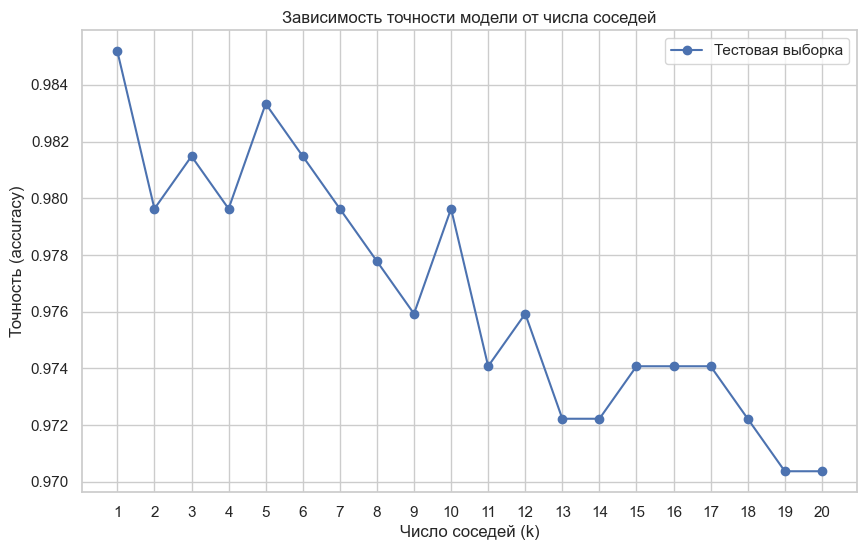

In [34]:
# Было созданы списки для хранения точности на обучающей и тестовой выборках
model_test_accuracy_st = []

for k in range(20) :

    # для каждого k была создана брутфорсная модель
    model = KNeighborsClassifier(n_neighbors = k + 1, algorithm = "brute")

    # затем она была обучена на обучающей выборке
    model.fit(X_train_scaled_df, y_train)

    # после того, как модель была обучена, она была использована для предсказаний на тестовой выборке
    y_test_pred_st = model.predict(X_test_scaled_df)

    # и были записаны результаты сравнения выборок
    model_test_accuracy_st.append(accuracy_score(y_test, y_test_pred_st))

# после получения необходимых данных были построены простые типичные графики для обеих выборок
# ньюанс: для построения графика нужно было создать список значений k k_values
k_values = range(1, 21)
plt.figure(figsize=(10, 6))
plt.plot(k_values, model_test_accuracy, label = "Тестовая выборка", marker = 'o')
plt.xlabel("Число соседей (k)")
plt.ylabel("Точность (accuracy)")
plt.title("Зависимость точности модели от числа соседей")
plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.show()

**Вывод:** Понятно, что параметр k = 1 соответствует недоообученной модели. В районе 5 - 10 точность модели показывает хорошие результаты без явного недообучения модели. Мне кажется, что на множестве других данных в этом районе будет в среднем монотонный несильный спад. Если известно, что выбросов в данных много, то лучше взять k = 10, иначе k = 5. 

В общем было обнаружено, что много мужчин погибло. Это объясняется тем, что сначала на спасательные лодки отправляли женщин. Также было замечено, что у людей с более высоким классом каюты шанс спастись был больше.